In [4]:
from pathlib import Path

REPORT_DIR = Path("calstrs_reports")

files = list(REPORT_DIR.glob("*.pdf"))

for f in sorted(files):
    print(f)

calstrs_reports/2020.pdf
calstrs_reports/2021.pdf
calstrs_reports/2022.pdf
calstrs_reports/2023.pdf
calstrs_reports/2024.pdf
calstrs_reports/2025.pdf


In [5]:
!pip install openai pymupdf pandas numpy scikit-learn matplotlib

In [7]:
import os
import re
import json
import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from openai import OpenAI

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
from pathlib import Path

REPORT_DIR = Path("calstrs_reports")

for f in sorted(REPORT_DIR.glob("*.pdf")):
    print(f)

calstrs_reports/2020.pdf
calstrs_reports/2021.pdf
calstrs_reports/2022.pdf
calstrs_reports/2023.pdf
calstrs_reports/2024.pdf
calstrs_reports/2025.pdf


In [9]:
def extract_pages(pdf_path):
    doc = fitz.open(pdf_path)

    pages = []

    for i, page in enumerate(doc):
        text = page.get_text("text")

        pages.append({
            "page": i + 1,
            "text": text
        })

    return pages


# Test with 2020 report
pages_2020 = extract_pages(REPORT_DIR / "2020.pdf")

print("Number of pages:", len(pages_2020))
print("\nFirst 1000 characters:\n")
print(pages_2020[0]["text"][:1000])


Number of pages: 28

First 1000 characters:

2020 Review of Funding Levels and Risks 
Presented December 9, 2020 



In [10]:
RISK_TERMS = [
    "risk",
    "investment",
    "volatility",
    "funding",
    "unfunded",
    "payroll",
    "membership",
    "longevity",
    "mortality",
    "recession",
    "uncertainty",
    "contribution",
    "actuarial",
    "maturity",
    "sustainability",
    "decline",
    "inflation"
]

def is_risk_relevant(text, min_terms=2):
    text_lower = text.lower()
    
    matches = sum(
        term in text_lower
        for term in RISK_TERMS
    )
    
    return matches >= min_terms

In [11]:
candidate_pages = []

for pdf_path in sorted(REPORT_DIR.glob("*.pdf")):
    
    year = int(pdf_path.stem)
    pages = extract_pages(pdf_path)
    
    for page in pages:
        
        if is_risk_relevant(page["text"]):
            
            candidate_pages.append({
                "year": year,
                "page": page["page"],
                "text": page["text"]
            })

candidate_df = pd.DataFrame(candidate_pages)

print("Total candidate pages:", len(candidate_df))

candidate_df.groupby("year").size()

Total candidate pages: 209


year
2020    28
2021    33
2022    37
2023    38
2024    37
2025    36
dtype: int64

In [12]:
candidate_df[
    ["year", "page"]
].head(20)

,year,page
0,2020,1
1,2020,2
2,2020,3
3,2020,4
4,2020,5
5,2020,6
6,2020,7
7,2020,8
8,2020,9
9,2020,10


In [13]:
sample = candidate_df.iloc[0]

print("Year:", sample["year"])
print("Page:", sample["page"])
print()
print(sample["text"][:2500])

Year: 2020
Page: 1

2020 Review of Funding Levels and Risks 
Presented December 9, 2020 



In [14]:
candidate_df.groupby("year").size()

year
2020    28
2021    33
2022    37
2023    38
2024    37
2025    36
dtype: int64

In [15]:
SECTION_TERMS = [
    "risk environment",
    "measures of plan maturity and volatility",
    "ability to reach full funding"
]

def is_risk_section(text):
    text_lower = text.lower()
    
    return any(
        section in text_lower
        for section in SECTION_TERMS
    )

In [16]:
candidate_pages = []

for pdf_path in sorted(REPORT_DIR.glob("*.pdf")):
    
    year = int(pdf_path.stem)
    pages = extract_pages(pdf_path)
    
    for page in pages:
        
        if is_risk_section(page["text"]):
            
            candidate_pages.append({
                "year": year,
                "page": page["page"],
                "text": page["text"]
            })

candidate_df = pd.DataFrame(candidate_pages)

print("Total selected pages:", len(candidate_df))
print()

print(candidate_df.groupby("year").size())

Total selected pages: 152

year
2020    18
2021    23
2022    28
2023    28
2024    28
2025    27
dtype: int64


In [17]:
candidate_df[["year", "page"]].to_string(index=False)

' year  page\n 2020    10\n 2020    11\n 2020    12\n 2020    13\n 2020    14\n 2020    15\n 2020    16\n 2020    17\n 2020    18\n 2020    19\n 2020    20\n 2020    21\n 2020    22\n 2020    23\n 2020    24\n 2020    25\n 2020    26\n 2020    27\n 2021     2\n 2021    11\n 2021    12\n 2021    13\n 2021    14\n 2021    15\n 2021    16\n 2021    17\n 2021    18\n 2021    19\n 2021    20\n 2021    21\n 2021    22\n 2021    23\n 2021    24\n 2021    25\n 2021    26\n 2021    27\n 2021    28\n 2021    29\n 2021    30\n 2021    31\n 2021    32\n 2022     2\n 2022     3\n 2022     7\n 2022    13\n 2022    14\n 2022    15\n 2022    16\n 2022    17\n 2022    18\n 2022    19\n 2022    20\n 2022    21\n 2022    22\n 2022    23\n 2022    24\n 2022    25\n 2022    26\n 2022    27\n 2022    28\n 2022    29\n 2022    30\n 2022    31\n 2022    32\n 2022    33\n 2022    34\n 2022    35\n 2022    36\n 2022    37\n 2023     2\n 2023     3\n 2023     4\n 2023    13\n 2023    14\n 2023    15\n 2023    16

In [18]:
print(candidate_df.groupby("year").size())

year
2020    18
2021    23
2022    28
2023    28
2024    28
2025    27
dtype: int64


In [19]:
# Words/phrases that indicate a passage may contain a substantive risk
RISK_CUES = [
    "risk",
    "uncertain",
    "uncertainty",
    "volatility",
    "decline",
    "decrease",
    "lower than",
    "below expectations",
    "recession",
    "loss",
    "unfunded",
    "shortfall",
    "pressure",
    "sensitivity",
    "maturity",
    "mortality",
    "longevity",
    "payroll",
    "membership",
    "contribution",
    "investment return",
    "actuarial assumption",
    "full funding",
    "economic stress",
    "sustainability"
]


def split_into_passages(text, max_chars=2500):
    """
    Break a PDF page into manageable text passages.
    """
    # Clean repeated whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    sentences = re.split(r'(?<=[.!?])\s+', text)

    passages = []
    current = ""

    for sentence in sentences:
        if len(current) + len(sentence) <= max_chars:
            current += " " + sentence
        else:
            if current.strip():
                passages.append(current.strip())
            current = sentence

    if current.strip():
        passages.append(current.strip())

    return passages


def contains_risk_cue(text):
    text_lower = text.lower()
    return any(cue in text_lower for cue in RISK_CUES)

In [20]:
risk_passages = []

for _, row in candidate_df.iterrows():

    passages = split_into_passages(row["text"])

    for passage in passages:

        if len(passage) >= 150 and contains_risk_cue(passage):

            risk_passages.append({
                "year": row["year"],
                "page": row["page"],
                "text": passage
            })


passage_df = pd.DataFrame(risk_passages)

print("Total candidate passages:", len(passage_df))
print()

print(passage_df.groupby("year").size())

Total candidate passages: 216

year
2020    32
2021    31
2022    39
2023    39
2024    37
2025    38
dtype: int64


In [21]:
for i in range(min(5, len(passage_df))):

    print("=" * 80)
    print(
        "Year:",
        passage_df.iloc[i]["year"],
        "| Page:",
        passage_df.iloc[i]["page"]
    )

    print()
    print(passage_df.iloc[i]["text"][:1200])
    print()

Year: 2020 | Page: 10

PATH TO FULL FUNDING The key assumption with this approach is the payroll growth assumption. For CalSTRS, payroll is assumed to increase annually at a rate of 3.5%. This means payments toward the unfunded actuarial obligation are expected to grow annually at a rate of 3.5%. The payments will be larger in 20 years than they are today even if the contribution rates remain the same. It is important to note that contribution rates and CalSTRS’ ability to reach full funding could be negatively affected in the future if payroll growth is less than 3.5%. This risk is discussed in more detail later in this report. Unallocated unfunded actuarial obligation While the funding plan has helped improve the long-term sustainability of the system, there are limitations in the plan as prescribed by statute. The constraints in the rate setting authority provided to the board, as well as other provisions in the funding plan, mean the entire unfunded actuarial obligation in place to

In [29]:
from getpass import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass(
    "Paste your OpenAI API key: "
)

Paste your OpenAI API key:  ········


In [30]:
from openai import OpenAI

client = OpenAI()

print("OpenAI client initialized.")


OpenAI client initialized.


In [31]:
from pydantic import BaseModel
from typing import List


class RiskItem(BaseModel):
    risk_statement: str
    risk_summary: str


class RiskExtraction(BaseModel):
    risks: List[RiskItem]

In [32]:
def extract_risks_with_llm(year, page, text):

    system_prompt = """
You are analyzing annual CalSTRS public pension disclosures.

Your task is to extract only material statements about risks,
challenges, concerns, uncertainty, adverse scenarios, or threats
to the long-term funding and sustainability of the pension plan.

Relevant risks may involve:
- investment performance or market volatility
- funding and unfunded liabilities
- contribution rates
- membership or payroll
- longevity or mortality
- actuarial assumptions
- pension plan maturity
- recession or macroeconomic conditions
- institutional or funding-plan constraints

Important rules:

1. Extract only risks explicitly supported by the supplied text.
2. Do not invent or infer risks that are not present.
3. Each item should represent one distinct economic risk.
4. Do not extract ordinary descriptive statements.
5. Do not classify the risks into categories yet.
6. Avoid duplicates within the same passage.
7. If the passage contains no material risk, return an empty list.
"""

    user_prompt = f"""
Report year: {year}
PDF page: {page}

PASSAGE:

{text}
"""

    response = client.responses.parse(
        model="gpt-5-mini",
        input=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        text_format=RiskExtraction
    )

    parsed = response.output_parsed

    results = []

    for risk in parsed.risks:

        results.append({
            "year": year,
            "page": page,
            "risk_statement": risk.risk_statement,
            "risk_summary": risk.risk_summary
        })

    return results

In [33]:
test_row = passage_df.iloc[0]

test_result = extract_risks_with_llm(
    year=int(test_row["year"]),
    page=int(test_row["page"]),
    text=test_row["text"]
)

test_df = pd.DataFrame(test_result)

test_df

,year,page,risk_statement,risk_summary
0,2020,10,It is important to note that contribution rate...,Payroll growth below the assumed 3.5% could hu...
1,2020,10,The constraints in the rate setting authority ...,Statutory rate-setting constraints mean the cu...
2,2020,10,"Pursuant to statute, the state is responsible ...",State contribution increases are capped at 0.5...
3,2020,10,"In fiscal year 2021–22, the board will be able...",Employer contribution adjustments are limited ...
4,2020,10,Since the employer’s share of the unfunded act...,The board cannot adjust rates to address any u...


In [34]:
import openai

print("OpenAI version:", openai.__version__)

OpenAI version: 3.5.0


In [35]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-5-mini",
    input="Say hello in one short sentence."
)

print(response.output_text)

Hello!


In [36]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-5-mini",
    input="Say hello in one short sentence."
)

print(response.output_text)

Hello!


In [37]:
test_row = passage_df.iloc[0]

test_result = extract_risks_with_llm(
    year=int(test_row["year"]),
    page=int(test_row["page"]),
    text=test_row["text"]
)

test_df = pd.DataFrame(test_result)

test_df

,year,page,risk_statement,risk_summary
0,2020,10,Contribution rates and CalSTRS’ ability to rea...,If payroll grows slower than the 3.5% assumpti...
1,2020,10,The constraints in the rate setting authority ...,Statutory and funding-plan constraints prevent...
2,2020,10,"Pursuant to statute, the state is responsible ...",State's share of UAO can only be addressed wit...
3,2020,10,"In fiscal year 2021–22, the board will be able...",Employer contribution increases are limited to...
4,2020,10,Since the employer’s share of the unfunded act...,The board lacks authority to adjust rates to a...


In [38]:
print("Total passages to process:", len(passage_df))
print()
print(passage_df.groupby("year").size())

Total passages to process: 216

year
2020    32
2021    31
2022    39
2023    39
2024    37
2025    38
dtype: int64


In [39]:
from tqdm.auto import tqdm
import time

all_extracted_risks = []

for idx, row in tqdm(
    passage_df.iterrows(),
    total=len(passage_df)
):

    try:
        risks = extract_risks_with_llm(
            year=int(row["year"]),
            page=int(row["page"]),
            text=row["text"]
        )

        # Add source information
        for risk in risks:
            risk["passage_id"] = idx
            risk["source_text"] = row["text"]

        all_extracted_risks.extend(risks)

    except Exception as e:
        print(
            f"\nProblem at passage {idx}, "
            f"year {row['year']}, "
            f"page {row['page']}: {e}"
        )

    # Save progress every 20 passages
    if (idx + 1) % 20 == 0:

        temp_df = pd.DataFrame(
            all_extracted_risks
        )

        temp_df.to_csv(
            "calstrs_risks_checkpoint.csv",
            index=False
        )

  0%|          | 0/216 [00:00<?, ?it/s]

In [40]:
risk_df = pd.DataFrame(
    all_extracted_risks
)

risk_df.to_csv(
    "calstrs_llm_risk_statements.csv",
    index=False
)

print("Number of extracted risks:", len(risk_df))
print()

print(
    risk_df.groupby("year")
    .size()
)

Number of extracted risks: 663

year
2020    105
2021     95
2022    123
2023    113
2024    113
2025    114
dtype: int64


In [41]:
risk_df[
    [
        "year",
        "page",
        "risk_statement",
        "risk_summary"
    ]
].head(20)

,year,page,risk_statement,risk_summary
0,2020,10,If payroll growth is less than the assumed 3.5...,Payroll growth shortfall relative to the 3.5% ...
1,2020,10,Statutory constraints on the board’s rate-sett...,Legal limitations prevent fully eliminating th...
2,2020,10,Statute limits the state to increasing its con...,Caps on annual contribution increases and rest...
3,2020,10,An unallocated unfunded actuarial obligation (...,Unallocated unfunded actuarial obligation proj...
4,2020,10,Because the board cannot adjust contribution r...,Constraint on board’s rate‑setting authority l...
5,2020,10,The unallocated UFAO could increase significan...,Funding level is sensitive to investment retur...
6,2020,10,If the unallocated UFAO were to be funded on a...,Actuarial funding of the unallocated obligatio...
7,2020,11,Volatility in investment returns could impact ...,Investment return volatility threatens funding...
8,2020,11,Improvements in longevity (members living long...,Rising longevity increases pension liabilities...
9,2020,11,Changes in payroll and the size of the active ...,Variations in payroll and active-member counts...


In [42]:
risk_counts = (
    risk_df
    .groupby("year")
    .size()
    .reset_index(name="number_of_risks")
)

risk_counts

,year,number_of_risks
0,2020,105
1,2021,95
2,2022,123
3,2023,113
4,2024,113
5,2025,114


In [43]:
for year in sorted(
    risk_df["year"].unique()
):

    print("\n" + "=" * 80)
    print("YEAR:", year)
    print("=" * 80)

    display(
        risk_df[
            risk_df["year"] == year
        ][
            [
                "page",
                "risk_statement",
                "risk_summary"
            ]
        ].head(10)
    )


YEAR: 2020


,page,risk_statement,risk_summary
0,10,If payroll growth is less than the assumed 3.5...,Payroll growth shortfall relative to the 3.5% ...
1,10,Statutory constraints on the board’s rate-sett...,Legal limitations prevent fully eliminating th...
2,10,Statute limits the state to increasing its con...,Caps on annual contribution increases and rest...
3,10,An unallocated unfunded actuarial obligation (...,Unallocated unfunded actuarial obligation proj...
4,10,Because the board cannot adjust contribution r...,Constraint on board’s rate‑setting authority l...
5,10,The unallocated UFAO could increase significan...,Funding level is sensitive to investment retur...
6,10,If the unallocated UFAO were to be funded on a...,Actuarial funding of the unallocated obligatio...
7,11,Volatility in investment returns could impact ...,Investment return volatility threatens funding...
8,11,Improvements in longevity (members living long...,Rising longevity increases pension liabilities...
9,11,Changes in payroll and the size of the active ...,Variations in payroll and active-member counts...



YEAR: 2021


,page,risk_statement,risk_summary
105,2,including longevity risk,Longevity risk
106,2,risks related to membership decline,Membership decline risk
107,2,risks related to ... future payroll growth,Future payroll growth risk
108,2,investment-related risk,Investment-related risk
109,2,These funds are intended to bridge the gap fro...,State contribution rate freeze creating a fund...
110,11,Longevity risk — members living longer than an...,"Members may outlive actuarial expectations, in..."
111,11,Risk of a decline in payroll / payroll growth ...,Declines in member payroll reduce contribution...
112,11,Investment-related risks.,Adverse investment performance or market volat...
113,11,COVID-19–driven demographic and assumption unc...,Pandemic-related changes in member behavior an...
114,11,It is not clear whether the pandemic will have...,Uncertainty about COVID-19's long-term impact ...



YEAR: 2022


...

,page,risk_statement,risk_summary
323,3,Longevity risk that increased life expectancy ...,Longer lifespans (longevity) may increase bene...
324,3,Risks related to membership decline that could...,Declining membership may reduce contributions ...
325,3,Uncertainty in future payroll growth that coul...,Slower or negative payroll growth would reduce...
326,3,"Investment-related risk, including poor invest...",Adverse investment performance or market volat...
327,3,Increasing plan maturity leading to greater co...,"As the plan matures, contribution rates may be..."
328,3,Changes to key economic and actuarial assumpti...,Revisions to economic or actuarial assumptions...
329,4,CalSTRS fell short of its 7% investment return...,Investment returns below the actuarial assumpt...
330,4,Demographic and economic changes could affect ...,Shifts in demographic or economic conditions m...
331,4,Investment-related risk is the largest risk fa...,Maturation of the DB program heightens sensiti...
332,4,A year in which investment returns are signifi...,A significant single-year investment shortfall...



YEAR: 2024


,page,risk_statement,risk_summary
436,3,Longevity risk could threaten long-term fundin...,Longer lifespans (longevity/mortality risk) ma...
437,3,Declines in membership and payroll could impai...,Reductions in active member counts or covered ...
438,3,"Investment-related risk, including investment ...",Adverse investment returns or market volatilit...
439,3,Changes to the investment return assumption co...,Lower assumed or realized investment returns t...
440,3,Increasing plan maturity can raise contributio...,"As the pension plan matures, higher maturity l..."
441,4,Prior to the 2014 adoption of the funding plan...,"Before the 2014 funding plan, the program face..."
442,4,Negative or below-assumed investment returns a...,Investment performance risk (negative returns/...
443,4,The Defined Benefit Program’s continued maturi...,Plan maturity increases sensitivity to investm...
444,4,A trigger that will reduce the state contribut...,Contribution-rate trigger reducing state contr...
445,4,The funding plan’s success depends on CalSTRS ...,Risk from failure to meet long-term actuarial ...



YEAR: 2025


,page,risk_statement,risk_summary
549,3,Longevity risk could endanger the long-term fu...,Increased member longevity (longevity risk) ma...
550,3,Risks related to membership and payroll declin...,Declines in active membership or covered payro...
551,3,Investment-related risk could endanger the lon...,Adverse investment performance or market-relat...
552,3,Increasing plan maturity may increase contribu...,Higher maturity levels can lead to greater vol...
553,3,Changes to the investment return assumption co...,A scenario of lower assumed or realized invest...
554,4,Prior to the 2014 adoption of the funding plan...,Risk that the Defined Benefit Program could de...
555,4,A year with investment returns significantly b...,Significantly below-assumed investment returns...
556,4,Investment-related risk is the largest risk to...,Investment risk heightened by system maturity ...
557,4,When the state fully eliminates its share of t...,Post-elimination trigger lowering state contri...
558,4,CalSTRS’ ability to reach full funding depends...,Uncertain investment markets could jeopardize ...


In [44]:
print("Number of extracted risks:", len(risk_df))

risk_df.groupby("year").size()

Number of extracted risks: 663


year
2020    105
2021     95
2022    123
2023    113
2024    113
2025    114
dtype: int64

# clean duplication 

In [45]:
risk_df.to_csv(
    "calstrs_llm_risk_statements_raw.csv",
    index=False
)

In [46]:
import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

risk_df["normalized_statement"] = (
    risk_df["risk_statement"]
    .apply(normalize_text)
)

print("Before removing duplicates:", len(risk_df))

risk_clean = (
    risk_df
    .drop_duplicates(
        subset=[
            "year",
            "page",
            "normalized_statement"
        ]
    )
    .reset_index(drop=True)
)

print("After removing exact duplicates:", len(risk_clean))

Before removing duplicates: 663
After removing exact duplicates: 663


In [47]:
risk_clean.groupby("year").size()

year
2020    105
2021     95
2022    123
2023    113
2024    113
2025    114
dtype: int64

# generate embedijng again 

In [48]:
EMBEDDING_MODEL = "text-embedding-3-small"

def get_embeddings(texts, batch_size=100):

    vectors = []

    for start in range(0, len(texts), batch_size):

        batch = texts[
            start:start + batch_size
        ]

        response = client.embeddings.create(
            model=EMBEDDING_MODEL,
            input=batch
        )

        vectors.extend(
            [item.embedding for item in response.data]
        )

    return np.array(vectors)

In [49]:
embeddings = get_embeddings(
    risk_clean["risk_statement"].tolist()
)

print("Embedding matrix shape:")
print(embeddings.shape)

Embedding matrix shape:
(663, 1536)


# deternince the numbers of clusters 

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_scores = {}

for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(embeddings)

    score = silhouette_score(
        embeddings,
        labels
    )

    cluster_scores[k] = score

    print(
        f"K={k}: silhouette score = {score:.4f}"
    )

K=2: silhouette score = 0.0590
K=3: silhouette score = 0.0688
K=4: silhouette score = 0.0735
K=5: silhouette score = 0.0855


In [51]:
best_k = max(
    cluster_scores,
    key=cluster_scores.get
)

print(
    "\nBest number of clusters:",
    best_k
)


Best number of clusters: 5


In [52]:
print("Before:", len(risk_df))
print("After:", len(risk_clean))

risk_clean.groupby("year").size()

Before: 663
After: 663


year
2020    105
2021     95
2022    123
2023    113
2024    113
2025    114
dtype: int64

In [53]:
cluster_scores

{2: 0.05895223647472282,
 3: 0.06878302859272012,
 4: 0.07352741862279367,
 5: 0.08545484387921073}

In [54]:
### use 5 clusters 

In [55]:
final_k = 5

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

risk_clean["cluster"] = kmeans.fit_predict(
    embeddings
)

print(
    risk_clean["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0     79
1    211
2    158
3    155
4     60
Name: count, dtype: int64


In [56]:
representatives = {}

for cluster in range(final_k):

    idx = np.where(
        risk_clean["cluster"].values == cluster
    )[0]

    centroid = kmeans.cluster_centers_[cluster]

    distances = np.linalg.norm(
        embeddings[idx] - centroid,
        axis=1
    )

    closest_idx = idx[
        np.argsort(distances)[:8]
    ]

    representatives[cluster] = (
        risk_clean.iloc[closest_idx][
            ["year", "page", "risk_statement", "risk_summary"]
        ]
    )

    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster}")
    print("=" * 100)

    for _, row in representatives[cluster].iterrows():

        print(
            f"\nYear {row['year']} | Page {row['page']}"
        )

        print("Risk:", row["risk_statement"])
        print("Summary:", row["risk_summary"])


CLUSTER 0

Year 2024 | Page 22
Risk: Long-term declines in active membership/payroll (scenarios of approximately 5%, 10% or 15% declines by 2046; Department of Finance projects a 15% K–12 enrollment decline over 20 years) can reduce payroll growth and the contribution base.
Summary: Projected reductions in membership and payroll growth could weaken contribution inflows and impair funding sustainability.

Year 2023 | Page 19
Risk: Projected sustained decline in K–12 public school enrollment (about 12% over the next 10 years; ~16% reduction compared to 2019–20) could reduce the number of active teachers participating in the Defined Benefit Program and slow payroll growth.
Summary: Long-term projected K–12 enrollment declines may reduce active teacher membership and pension payroll growth.

Year 2023 | Page 35
Risk: Anticipated reductions in K–12 enrollment that lead to fewer teachers participating in the Defined Benefit Program could decrease active membership and payroll growth, negati

In [57]:
cluster_by_year = pd.crosstab(
    risk_clean["year"],
    risk_clean["cluster"]
)

cluster_by_year

cluster,0,1,2,3,4
year,,,,,
2020,12,40,20,24,9
2021,15,31,18,22,9
2022,15,30,35,30,13
2023,12,31,30,29,11
2024,13,40,26,26,8
2025,12,39,29,24,10


### C(II): naming the clusters.

In [58]:
representative_tables = {}

for cluster in range(5):

    # Positions belonging to this cluster
    idx = np.where(
        risk_clean["cluster"].values == cluster
    )[0]

    # Cluster centroid
    centroid = kmeans.cluster_centers_[cluster]

    # Distance from every statement in cluster to centroid
    distances = np.linalg.norm(
        embeddings[idx] - centroid,
        axis=1
    )

    # Six closest statements
    closest_idx = idx[
        np.argsort(distances)[:6]
    ]

    rep = risk_clean.iloc[closest_idx][
        [
            "year",
            "page",
            "risk_statement",
            "risk_summary"
        ]
    ]

    representative_tables[cluster] = rep

    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster}")
    print("=" * 100)

    for _, row in rep.iterrows():

        print(
            f"\nYear {row['year']} | Page {row['page']}"
        )

        print("Risk statement:")
        print(row["risk_statement"])

        print("Summary:")
        print(row["risk_summary"])


CLUSTER 0

Year 2024 | Page 22
Risk statement:
Long-term declines in active membership/payroll (scenarios of approximately 5%, 10% or 15% declines by 2046; Department of Finance projects a 15% K–12 enrollment decline over 20 years) can reduce payroll growth and the contribution base.
Summary:
Projected reductions in membership and payroll growth could weaken contribution inflows and impair funding sustainability.

Year 2023 | Page 19
Risk statement:
Projected sustained decline in K–12 public school enrollment (about 12% over the next 10 years; ~16% reduction compared to 2019–20) could reduce the number of active teachers participating in the Defined Benefit Program and slow payroll growth.
Summary:
Long-term projected K–12 enrollment declines may reduce active teacher membership and pension payroll growth.

Year 2023 | Page 35
Risk statement:
Anticipated reductions in K–12 enrollment that lead to fewer teachers participating in the Defined Benefit Program could decrease active members

## Now map the cluster names

In [59]:
cluster_names = {
    0: "Membership & Payroll Demographic Risk",
    1: "Investment & Market Volatility Risk",
    2: "Actuarial Assumption & Funding Sustainability Risk",
    3: "Contribution Rate & Funding Plan Risk",
    4: "Longevity & Mortality Risk"
}

risk_clean["risk_category"] = (
    risk_clean["cluster"]
    .map(cluster_names)
)

risk_clean[
    [
        "year",
        "cluster",
        "risk_category",
        "risk_statement"
    ]
].head(10)

,year,cluster,risk_category,risk_statement
0,2020,2,Actuarial Assumption & Funding Sustainability ...,If payroll growth is less than the assumed 3.5...
1,2020,3,Contribution Rate & Funding Plan Risk,Statutory constraints on the board’s rate-sett...
2,2020,3,Contribution Rate & Funding Plan Risk,Statute limits the state to increasing its con...
3,2020,3,Contribution Rate & Funding Plan Risk,An unallocated unfunded actuarial obligation (...
4,2020,3,Contribution Rate & Funding Plan Risk,Because the board cannot adjust contribution r...
5,2020,1,Investment & Market Volatility Risk,The unallocated UFAO could increase significan...
6,2020,3,Contribution Rate & Funding Plan Risk,If the unallocated UFAO were to be funded on a...
7,2020,2,Actuarial Assumption & Funding Sustainability ...,Volatility in investment returns could impact ...
8,2020,4,Longevity & Mortality Risk,Improvements in longevity (members living long...
9,2020,2,Actuarial Assumption & Funding Sustainability ...,Changes in payroll and the size of the active ...


In [60]:
risk_clean.to_csv(
    "calstrs_risks_classified.csv",
    index=False
)

## C(III): Build the frequency table


In [61]:
frequency = pd.crosstab(
    risk_clean["year"],
    risk_clean["risk_category"]
)

frequency

risk_category,Actuarial Assumption & Funding Sustainability Risk,Contribution Rate & Funding Plan Risk,Investment & Market Volatility Risk,Longevity & Mortality Risk,Membership & Payroll Demographic Risk
year,,,,,
2020,20,24,40,9,12
2021,18,22,31,9,15
2022,35,30,30,13,15
2023,30,29,31,11,12
2024,26,26,40,8,13
2025,29,24,39,10,12


## Plot required by the homework


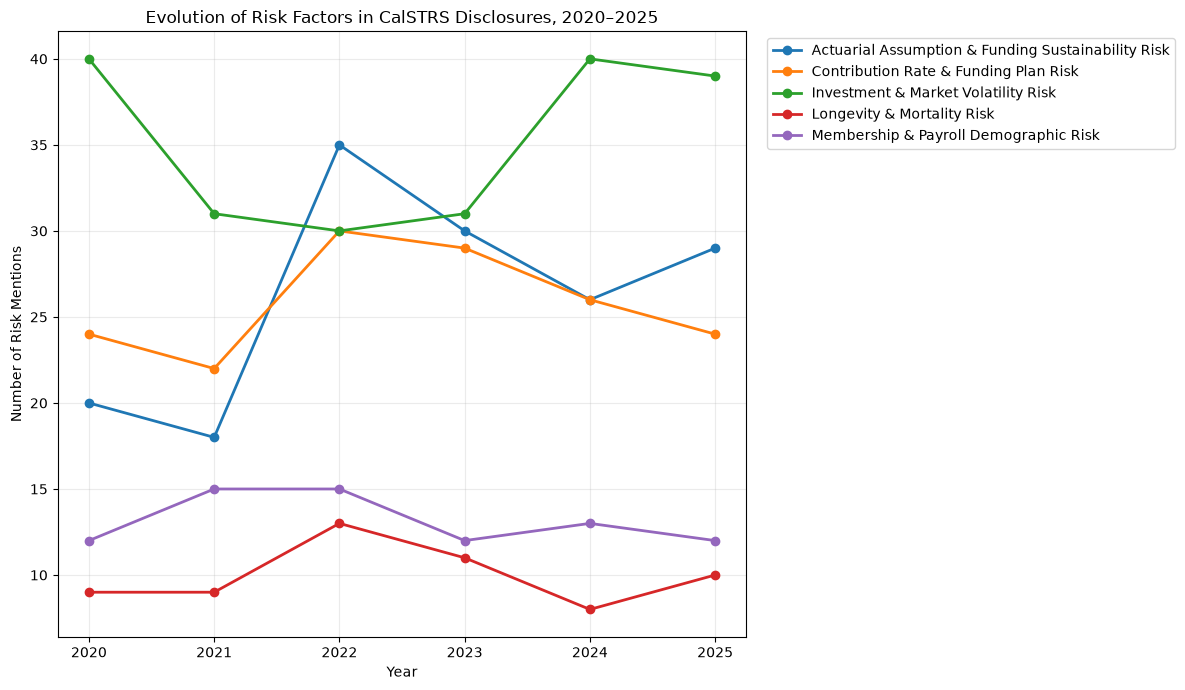

In [62]:
plt.figure(figsize=(12, 7))

for category in frequency.columns:

    plt.plot(
        frequency.index,
        frequency[category],
        marker="o",
        linewidth=2,
        label=category
    )

plt.xlabel("Year")
plt.ylabel("Number of Risk Mentions")

plt.title(
    "Evolution of Risk Factors in CalSTRS Disclosures, 2020–2025"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "calstrs_risk_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Also calculate shares


In [63]:
risk_share = (
    frequency
    .div(frequency.sum(axis=1), axis=0)
    * 100
)

risk_share.round(1)

risk_category,Actuarial Assumption & Funding Sustainability Risk,Contribution Rate & Funding Plan Risk,Investment & Market Volatility Risk,Longevity & Mortality Risk,Membership & Payroll Demographic Risk
year,,,,,
2020,19.0,22.9,38.1,8.6,11.4
2021,18.9,23.2,32.6,9.5,15.8
2022,28.5,24.4,24.4,10.6,12.2
2023,26.5,25.7,27.4,9.7,10.6
2024,23.0,23.0,35.4,7.1,11.5
2025,25.4,21.1,34.2,8.8,10.5


## Make the final C(III) figure


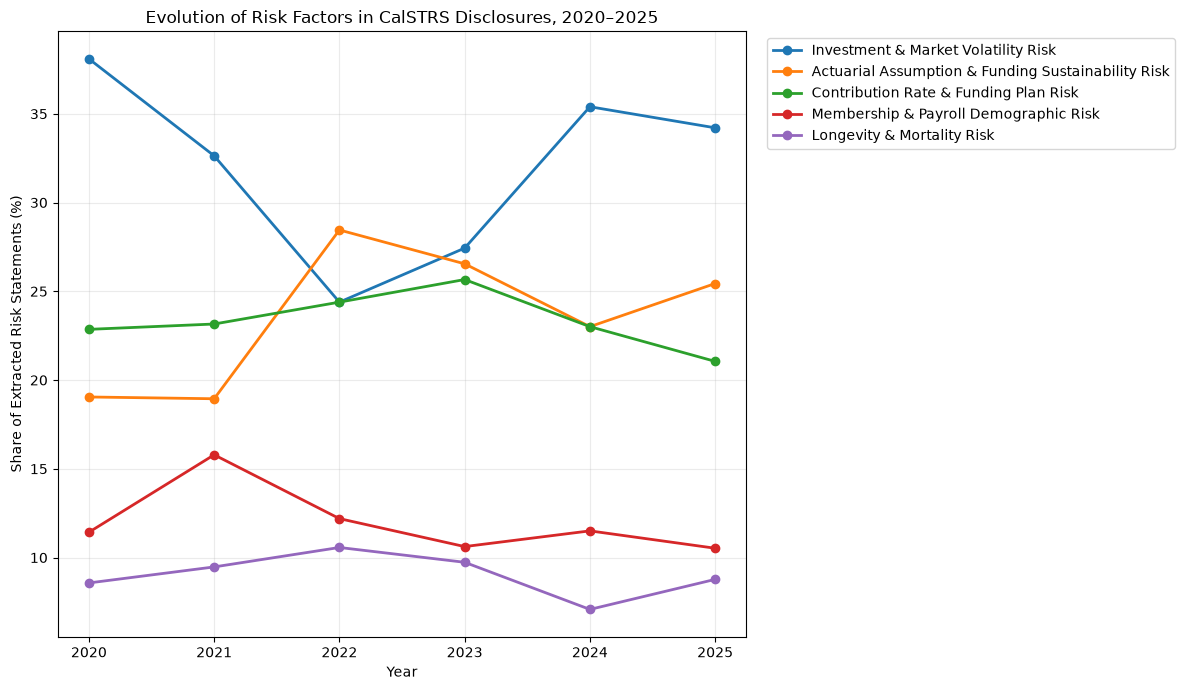

In [64]:
# Put categories in a logical order
category_order = [
    "Investment & Market Volatility Risk",
    "Actuarial Assumption & Funding Sustainability Risk",
    "Contribution Rate & Funding Plan Risk",
    "Membership & Payroll Demographic Risk",
    "Longevity & Mortality Risk"
]

risk_share_plot = risk_share[category_order]

plt.figure(figsize=(12, 7))

for category in risk_share_plot.columns:
    plt.plot(
        risk_share_plot.index,
        risk_share_plot[category],
        marker="o",
        linewidth=2,
        label=category
    )

plt.xlabel("Year")
plt.ylabel("Share of Extracted Risk Statements (%)")

plt.title(
    "Evolution of Risk Factors in CalSTRS Disclosures, 2020–2025"
)

plt.xticks(risk_share_plot.index)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "calstrs_risk_share_2020_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()